# Smart Customer Data Reconciliation Engine
### Entity resolution for messy business records (Excel ↔ CRM)

**The problem.** Small businesses keep the same customers in several disconnected systems — a spreadsheet, a CRM, an invoicing tool. The same customer appears as `Summit Construction Inc`, `SUMMIT CONSTRUCTION`, and `summit  contruction llc`. Off-the-shelf sync tools treat these as three different customers and create duplicates. Reliably deciding *which records refer to the same real-world entity* is a classic, hard ML problem called **entity resolution** (a.k.a. record linkage / deduplication).

**What this notebook does.** It takes two messy customer exports, engineers string-similarity features, and trains a model to decide which record pairs are the same customer — then outputs one clean, unified table with confidence scores.

**Skills demonstrated:** data cleaning · blocking for scalable pair generation · feature engineering · a supervised classifier vs. a rules baseline · proper evaluation (precision / recall / F1, confusion matrix, feature importance).

> Built as a portfolio project. The pipeline is real; the data is synthetic but deliberately messy, with a hidden ground-truth key so we can measure accuracy.

## 0. Setup

In [1]:
!pip install rapidfuzz -q
import numpy as np, pandas as pd, random, re
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
random.seed(42); np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\ppran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Generate realistic messy data
We simulate two exports of the *same* customer base — one from a spreadsheet, one from a CRM. Each record carries a hidden `true_id` (the real customer) so we can grade ourselves later. Not every customer appears in both systems, and the ones that do are messed up **independently**: name variants (`Inc`/`Incorporated`/`LLC`), casing, typos, phone reformatting, email typos, and missing values.

In [2]:
N_CUSTOMERS = 5000

first=["James","Maria","Wei","Aisha","Carlos","Priya","John","Sara","Tom","Nina","Omar","Lena","Raj","Kate","Diego"]
last=["Smith","Nguyen","Patel","Johnson","Garcia","Kim","Brown","Lopez","Davis","Ali","Chen","Rossi","Khan","Meyer","Silva"]

# The company-name vocabulary has to scale with N_CUSTOMERS. With too few distinct
# names, many genuinely different customers end up sharing one company name and differ
# only by contact/email/phone -- fields that are 10-30% missing. Those pairs are
# unresolvable even in principle, so F1 falls for reasons that have nothing to do with
# the model. 146 x 14 = 2,044 names holds name reuse at ~2.4x for n=5000, matching the
# ~2.5x the original n=300 setup had, so the two runs stay comparable.
biz=["Summit","Ironclad","Blue Ridge","Apex","Redwood","Keystone","Vanguard","Copper","Granite","Northstar",
     "Elm","Harbor","Cascade","Pioneer","Falcon","Bedrock","Cornerstone","Timberline","Ridgeline","Stonegate",
     "Anvil","Beacon","Crestview","Dunmore","Eagle","Foxhill","Gatewood","Hallmark","Ivywood","Juniper",
     "Kingfisher","Lakeshore","Maplewood","Nightingale","Oakmont","Prairie","Quarry","Riverbend","Sandstone","Trailhead",
     "Umbra","Verdant","Westgate","Yarrow","Zenith","Alder","Basalt","Cedar","Dogwood","Everest",
     "Ferngrove","Goldleaf","Hearthstone","Inlet","Jetstream","Kestrel","Larkspur","Millstone","Norwood","Oriole",
     "Pinnacle","Quicksilver","Rockford","Silverton","Thistle","Uplands","Vireo","Wildwood","Xavier","Yellowstone",
     "Zephyr","Ashford","Brightwater","Cobalt","Driftwood","Emberton","Flintlock","Glenrock","Hollowbrook","Ironwood",
     "Jackpine","Kelvin","Lodestone","Marblehead","Nimbus","Overlook","Palisade","Quill","Ravenswood","Stillwater",
     "Torchlight","Underhill","Valemont","Whetstone","Yorkfield","Zircon","Amberly","Bluestem","Clearview","Deepwell",
     "Eastvale","Fairmount","Greystone","Highfield","Innisfree","Junction","Kingsley","Longmeadow","Meridian","Northfield",
     "Oakhurst","Parkland","Quantum","Redstone","Southbend","Trinity","Upton","Valley","Windward","Yeoman",
     "Zenwood","Arrowhead","Birchwood","Coalfield","Dovetail","Elkhorn","Foundry","Greenfield","Hammerton","Ivyridge",
     "Jasper","Kirkwood","Limestone","Mossbank","Nolanville","Orchard","Pembroke","Quinton","Rosewood","Saltcreek",
     "Tanglewood","Ulster","Vantage","Waverly","Yardley","Zenobia"]
suf=["Construction","Builders","Contracting","Roofing","Electric","Plumbing","Concrete",
     "Landscaping","Excavation","Masonry","HVAC","Drywall","Paving","Carpentry"]
cities=[("Austin","TX","7870"),("Denver","CO","8020"),("Tampa","FL","3360"),("Reno","NV","8950"),("Boise","ID","8370"),("Mesa","AZ","8520")]

def make_base(n=N_CUSTOMERS):
    rows=[]
    for i in range(n):
        c,s,z=random.choice(cities)
        b=random.choice(biz)
        rows.append(dict(true_id=i,
            company=f"{b} {random.choice(suf)}",
            contact=f"{random.choice(first)} {random.choice(last)}",
            email=f"contact{i}@{b.lower().replace(' ','')}co.com",
            phone=f"{random.randint(200,999)}{random.randint(200,999)}{random.randint(1000,9999)}",
            city=c,state=s,zip=f"{z}{random.randint(0,9)}"))
    return pd.DataFrame(rows)

INC=["Inc","Inc.","Incorporated","LLC","Co","Co.",""]
def messy_company(name):
    if random.random()<0.6: name=name+" "+random.choice(INC)
    if random.random()<0.3: name=name.upper()
    if random.random()<0.2: name=name.replace(" ","  ")
    if random.random()<0.15:
        j=random.randint(1,len(name)-1); name=name[:j]+name[j-1]+name[j+1:]  # transposition typo
    return name.strip()

def messy_phone(p):
    if random.random()<0.15:  # number changed between systems
        p=f"{random.randint(200,999)}{random.randint(200,999)}{random.randint(1000,9999)}"
    return random.choice([p, f"({p[:3]}) {p[3:6]}-{p[6:]}", f"{p[:3]}-{p[3:6]}-{p[6:]}", f"+1{p}"])

def messy_email(e):
    if random.random()<0.2: e=e.replace(".com",".co")
    if random.random()<0.15: e=e.upper()
    return e

def make_source(base, drop_frac):
    df=base.sample(frac=1-drop_frac, random_state=random.randint(0,9999)).copy()
    df["company"]=df["company"].apply(messy_company)
    df["contact"]=df["contact"].apply(lambda x: x.upper() if random.random()<0.25 else x)
    df["phone"]=df["phone"].apply(messy_phone)
    df["email"]=df["email"].apply(messy_email)
    df.loc[df.sample(frac=0.10).index,"email"]=None
    df.loc[df.sample(frac=0.10).index,"contact"]=None
    df.loc[df.sample(frac=0.30).index,"phone"]=None
    return df.reset_index(drop=True)

base=make_base(N_CUSTOMERS)
excel=make_source(base,0.15); crm=make_source(base,0.15)
excel.to_csv("excel_source.csv",index=False); crm.to_csv("crm_source.csv",index=False)
overlap=set(excel.true_id)&set(crm.true_id)
print(f"Excel rows: {len(excel):,} | CRM rows: {len(crm):,} | true customers in BOTH: {len(overlap):,}")
print(f"Distinct company names available: {len(biz)*len(suf):,} | name reuse: {N_CUSTOMERS/(len(biz)*len(suf)):.1f}x")
excel.head(4)

Excel rows: 4,250 | CRM rows: 4,250 | true customers in BOTH: 3,600
Distinct company names available: 2,044 | name reuse: 2.4x


,true_id,company,contact,email,phone,city,state,zip
0,2587,Zephyr Landscaping,Carlos Johnson,CONTACT2587@ZEPHYRCO.COM,+16103792871,Boise,ID,83703
1,4139,Valley Electric Co.,MARIA CHEN,contact4139@valleyco.com,NaN,Boise,ID,83708
2,1087,JUNIPER DRYWALL LLC,Omar Lopez,CONTACT1087@JUNIPERCO.COM,383-386-7438,Austin,TX,78700
3,1298,Bedrocc Drywall,Wei Khan,contact1298@bedrockco.co,9773965249,Denver,CO,80206


## 2. Explore the mess
Here is one real customer as it appears in each system — same `true_id`, very different text. This is what breaks naive matching.

In [3]:
common = list(overlap)[:1][0]
pd.concat([
    excel[excel.true_id==common].assign(source="EXCEL"),
    crm[crm.true_id==common].assign(source="CRM")
])[["source","company","contact","email","phone"]]

,source,company,contact,email,phone
3857,EXCEL,Ivvwood Construction,Lena Garcia,contact0@ivywoodco.co,+14504283286
1840,CRM,Ivywood Construction,Lena Garcia,contact0@ivywoodco.com,(450) 428-3286


## 3. Clean & standardize
Lowercase, strip punctuation, remove legal suffixes (`inc`, `llc`), collapse whitespace; reduce phones to bare digits and emails to lowercase. These normalized columns are what every later step compares — and what the blocking keys in the next section are built from.

In [4]:
def norm(s):
    if pd.isna(s): return ""
    s=str(s).lower(); s=re.sub(r"[^a-z0-9 ]"," ",s)
    s=re.sub(r"\b(inc|incorporated|llc|co)\b"," ",s)
    return re.sub(r"\s+"," ",s).strip()
def digits(s): return re.sub(r"\D","",str(s)) if pd.notna(s) else ""

for d in (excel, crm):
    d["company_n"]=d["company"].apply(norm)
    d["contact_n"]=d["contact"].apply(norm)
    d["email_n"]=d["email"].fillna("").str.lower()
    d["phone_n"]=d["phone"].apply(digits)
excel[["company","company_n","phone","phone_n"]].head(4)

,company,company_n,phone,phone_n
0,Zephyr Landscaping,zephyr landscaping,+16103792871,16103792871
1,Valley Electric Co.,valley electric,NaN,
2,JUNIPER DRYWALL LLC,juniper drywall,383-386-7438,3833867438
3,Bedrocc Drywall,bedrocc drywall,9773965249,9773965249


## 4. Blocking — make comparison scalable

Comparing every Excel row to every CRM row is O(n×m) — 18 million comparisons here, growing
quadratically. **Blocking** only compares records that share a cheap key, slashing the pair count.
The risk: a bad key silently discards true matches before the model ever sees them.

**Blocking recall — the share of true matches retained — is a hard ceiling on the whole pipeline.**
A pair that never becomes a candidate cannot be recovered by any feature, any model, or any amount
of tuning downstream. It is the first number to check and the last one people think to look at.

### Why one key isn't enough

A single key on the company name fails whenever the mess lands *inside that key*. A transposition
typo in the first three characters (`Dunmore` → `DDnmore`) puts two records in different blocks and
they are lost — even though they agree perfectly on an exact phone number or an email local part.

So we use **multi-pass blocking**: generate candidates from several cheap keys and take the union.
A pair survives if *any* key matches, so each key only has to work some of the time.

| Pass | Key | Catches |
|---|---|---|
| 1 | first 3 chars of normalized company | the common case |
| 2 | exact normalized phone | company name mangled, phone intact |
| 3 | email local part (before the `@`) | name mangled *and* domain corrupted (`.com`→`.co`), local part intact |

The passes are deliberately **cheap and exact** — hashable keys, no fuzzy comparison. Blocking must
stay near-linear or it defeats its own purpose. Passes 2 and 3 are nearly free because phone and
email are high-selectivity: they add very few pairs while rescuing the ones the name key drops.

In [5]:
def block_keys(df):
    """Each record's set of blocking keys. Tagged so keys from different passes can
    never collide (a phone that looks like a name prefix stays in its own namespace)."""
    comp, ph, em = df.company_n.to_numpy(), df.phone_n.to_numpy(), df.email_n.to_numpy()
    out = []
    for k in range(len(df)):
        s = set()
        if comp[k]:            s.add(("name",  comp[k][:3]))
        if len(ph[k]) >= 10:   s.add(("phone", ph[k]))
        if "@" in em[k]:       s.add(("email", em[k].split("@")[0]))
        out.append(s)
    return out

def candidate_pairs(left_keys, right_keys, passes=None):
    """Union of pairs sharing any key. `passes` optionally restricts which key types
    are used, so we can measure each pass's contribution in isolation."""
    keep = (lambda kind: True) if passes is None else (lambda kind: kind in passes)
    idx = {}
    for j, ks in enumerate(right_keys):
        for kind, val in ks:
            if keep(kind): idx.setdefault((kind, val), []).append(j)
    pairs = set()
    for i, ks in enumerate(left_keys):
        for kind, val in ks:
            if keep(kind):
                for j in idx.get((kind, val), ()): pairs.add((i, j))
    return pairs

ek, ck = block_keys(excel), block_keys(crm)
brute  = len(excel) * len(crm)
e_tid, c_tid = excel.true_id.to_numpy(), crm.true_id.to_numpy()
recall = lambda ps: sum(e_tid[i] == c_tid[j] for i, j in ps) / len(overlap)

# What does each pass buy us? Blocking design is a recall/cost tradeoff, so measure it.
print(f"{'passes':<34}{'pairs':>10}{'recall':>9}{'reduction':>11}")
for label, sel in [("name only (single-key)", {"name"}),
                   ("name + phone",           {"name","phone"}),
                   ("name + email",           {"name","email"}),
                   ("name + phone + email",   None)]:
    ps = candidate_pairs(ek, ck, sel)
    print(f"{label:<34}{len(ps):>10,}{100*recall(ps):>8.2f}%{100*(1-len(ps)/brute):>10.2f}%")

pairs = sorted(candidate_pairs(ek, ck))
ei = np.fromiter((p[0] for p in pairs), dtype=np.int32, count=len(pairs))
ci = np.fromiter((p[1] for p in pairs), dtype=np.int32, count=len(pairs))
y  = (e_tid[ei] == c_tid[ci]).astype(int)

print(f"\nCandidate pairs: {len(ei):,}  (vs {brute:,} brute force"
      f" -> {100*(1-len(ei)/brute):.1f}% fewer comparisons)")
print(f"Blocking recall: {100*y.sum()/len(overlap):.2f}% of true matches retained"
      f"  ({len(overlap)-y.sum()} of {len(overlap):,} lost before the model sees them)")

passes                                 pairs   recall  reduction
name only (single-key)               156,070   97.06%     99.14%


name + phone                         156,100   97.89%     99.14%


name + email                         156,160   99.56%     99.14%


name + phone + email                 156,166   99.72%     99.14%



Candidate pairs: 156,166  (vs 18,062,500 brute force -> 99.1% fewer comparisons)
Blocking recall: 99.72% of true matches retained  (10 of 3,600 lost before the model sees them)


## 5. Similarity features
For each candidate pair we compute string-similarity scores with `rapidfuzz` — these are the model's inputs. `token_sort_ratio` handles word reordering; `partial_ratio` handles substrings; exact phone match is a strong (but noisy) signal.

In [6]:
import time
FEATURES=["company_sort","company_partial","contact_sort","email","phone"]

def build_features(ei,ci):
    # Pull each column out to a plain numpy array once, then index into it. Touching
    # pandas inside the loop (.iloc / attribute access on a row) dominates the runtime
    # at this pair count; rapidfuzz on raw strings is the only work left.
    ec,cc=excel.company_n.to_numpy(),crm.company_n.to_numpy()
    en,cn=excel.contact_n.to_numpy(),crm.contact_n.to_numpy()
    ee,ce=excel.email_n.to_numpy(),crm.email_n.to_numpy()
    ep,cp=excel.phone_n.to_numpy(),crm.phone_n.to_numpy()
    X=np.empty((len(ei),len(FEATURES)),dtype=np.float32)
    for k in range(len(ei)):
        i,j=ei[k],ci[k]
        pa,pb=ep[i],cp[j]
        X[k,0]=fuzz.token_sort_ratio(ec[i],cc[j])
        X[k,1]=fuzz.partial_ratio(ec[i],cc[j])
        X[k,2]=fuzz.token_sort_ratio(en[i],cn[j])
        X[k,3]=fuzz.ratio(ee[i],ce[j])
        X[k,4]=100.0 if pa and pa==pb else fuzz.ratio(pa,pb)
    return X

t0=time.time(); X=build_features(ei,ci); secs=time.time()-t0
print(f"Feature matrix: {X.shape} | positive pairs: {int(y.sum()):,} / {len(y):,}"
      f" ({100*y.mean():.2f}% positive)")
print(f"Built in {secs:.1f}s ({len(ei)/secs:,.0f} pairs/sec)")

Feature matrix: (156166, 5) | positive pairs: 3,590 / 156,166 (2.30% positive)
Built in 1.9s (83,427 pairs/sec)


### Do matches actually separate from non-matches?
If the classes overlap completely, no model can help. This histogram is a quick sanity check.

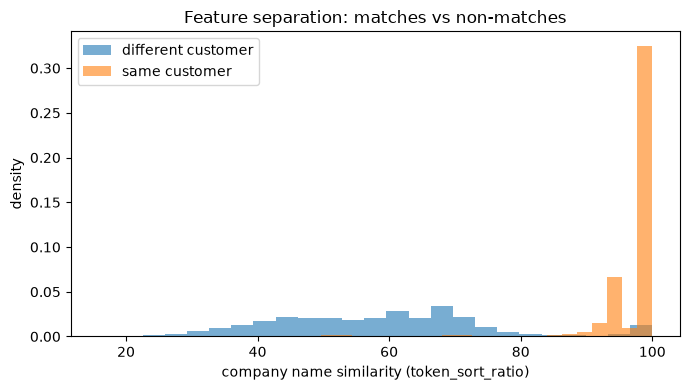

In [7]:
plt.hist(X[y==0,0],bins=25,alpha=.6,label="different customer",density=True)
plt.hist(X[y==1,0],bins=25,alpha=.6,label="same customer",density=True)
plt.xlabel("company name similarity (token_sort_ratio)"); plt.ylabel("density")
plt.title("Feature separation: matches vs non-matches"); plt.legend(); plt.tight_layout(); plt.show()

## 6. Baseline: naive threshold matcher (the "before")
What the cheap existing tools effectively do: call it a match if the company names are similar enough. We sweep the threshold. Note the weak precision — this is the problem we're improving on.

In [8]:
print("thr | precision recall  f1")
for t in (80,85,90,95):
    pred=(X[:,0]>=t).astype(int)
    print(f"{t:>3} |   {precision_score(y,pred):.2f}    {recall_score(y,pred):.2f}  {f1_score(y,pred):.2f}")

thr | precision recall  f1
 80 |   0.24    0.97  0.38
 85 |   0.27    0.97  0.42


 90 |   0.29    0.96  0.45
 95 |   0.29    0.79  0.42


## 7. ML classifier (the "after")
Instead of one hand-picked threshold, learn how to weigh **all** the features together. Train/test split, Random Forest, evaluate on held-out pairs.

Random Forest  ->  precision 0.939 | recall 0.994 | F1 0.966


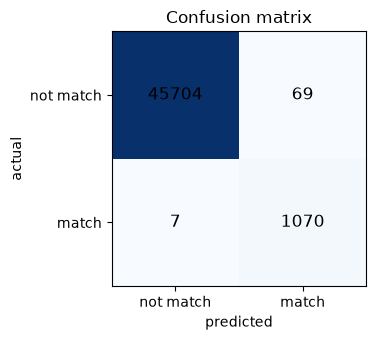

In [9]:
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
clf=RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced").fit(Xtr,ytr)
pred=clf.predict(Xte)
P,R,F=precision_score(yte,pred),recall_score(yte,pred),f1_score(yte,pred)
print(f"Random Forest  ->  precision {P:.3f} | recall {R:.3f} | F1 {F:.3f}")

cm=confusion_matrix(yte,pred)
fig,ax=plt.subplots(figsize=(4,3.5)); im=ax.imshow(cm,cmap="Blues")
for (i,j),v in np.ndenumerate(cm): ax.text(j,i,v,ha="center",va="center",fontsize=12)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["not match","match"]); ax.set_yticklabels(["not match","match"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Confusion matrix"); plt.tight_layout(); plt.show()

### Which features drove the decision?
Interpretability matters in interviews — be ready to explain *why* the model works.

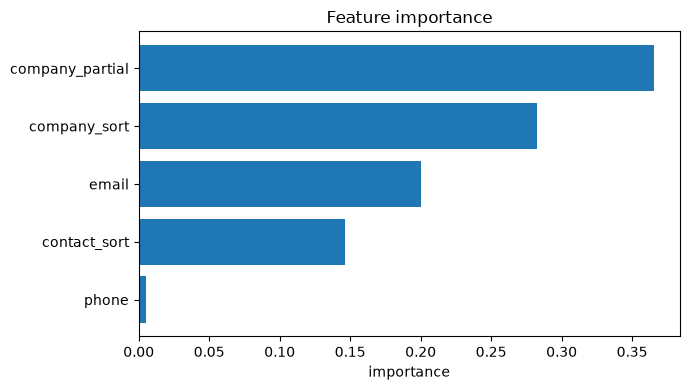

In [10]:
imp=clf.feature_importances_
order=np.argsort(imp)
plt.barh([FEATURES[i] for i in order],[imp[i] for i in order])
plt.xlabel("importance"); plt.title("Feature importance"); plt.tight_layout(); plt.show()

### Baseline vs ML — the headline result

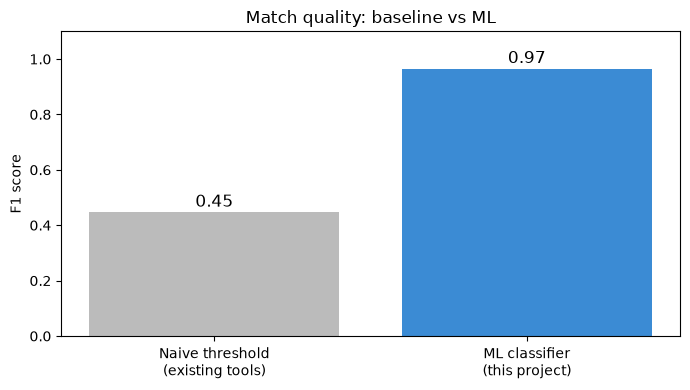

F1 improved from 0.45 (baseline) to 0.97 (ML) — a 116% relative gain


In [11]:
base_f1=max(f1_score(y,(X[:,0]>=t).astype(int)) for t in range(70,100))
plt.bar(["Naive threshold\n(existing tools)","ML classifier\n(this project)"],[base_f1,F],
        color=["#bbb","#3B8BD4"])
for i,v in enumerate([base_f1,F]): plt.text(i,v+.02,f"{v:.2f}",ha="center",fontsize=12)
plt.ylabel("F1 score"); plt.ylim(0,1.1); plt.title("Match quality: baseline vs ML"); plt.tight_layout(); plt.show()
print(f"F1 improved from {base_f1:.2f} (baseline) to {F:.2f} (ML) — a {100*(F-base_f1)/base_f1:.0f}% relative gain")

## 8. Produce the unified, deduplicated table
Apply the model to every candidate pair, keep confident matches, and greedily enforce one-to-one links (each record matches at most one other). The output is the clean, merged customer list a sync tool would push downstream — each row tagged with a **match confidence**.

In [12]:
proba=clf.predict_proba(X)[:,1]
keep=np.flatnonzero(proba>=0.5)
keep=keep[np.argsort(-proba[keep])]   # greedy one-to-one: settle the confident links first

COLS=["company","contact","email","phone","true_id"]
e_rows=excel[COLS].to_numpy(dtype=object); c_rows=crm[COLS].to_numpy(dtype=object)

used_e,used_c,merged=set(),set(),[]
for k in keep:
    i,j=int(ei[k]),int(ci[k])
    if i in used_e or j in used_c: continue
    used_e.add(i); used_c.add(j)
    a,b=e_rows[i],c_rows[j]
    merged.append(dict(confidence=round(float(proba[k]),3),
        company=a[0], company_crm=b[0],
        contact=a[1] or b[1], email=a[2] or b[2],
        phone=a[3] or b[3], correct=bool(a[4]==b[4])))
unified=pd.DataFrame(merged)
unified.to_csv("unified_customers.csv",index=False)
print(f"Merged {len(unified):,} customer records | live accuracy: {100*unified.correct.mean():.1f}%")
unified.drop(columns="correct").head(8)

Merged 3,582 customer records | live accuracy: 99.4%


,confidence,company,company_crm,contact,email,phone
0,1.0,Glenrock Construction Co,Glenrock Construction Co.,Carlos Johnson,contact741@glenrockco.com,+14195221355
1,1.0,QUARRY PAVING,QUARRY PAVING INCORPORATED,Maria Meyer,CONTACT472@QUARRYCO.COM,+17385732188
2,1.0,Amberly Electric Incorporated,Amberly Electric,JOHN KHAN,contact2395@amberlyco.co,NaN
3,1.0,Rooewood Landscaping,Rosewood Landssaping,Carlos Lopez,contact2376@rosewoodco.com,+17349862255
4,1.0,Tanglewood Carpentry Inc.,Tanglewood Carpentry Co.,NINA ALI,contact3192@tanglewoodco.com,8182502313
5,1.0,Limestone Electric,LIMESTONE ELECTRIC CO.,Tom Patel,contact2380@limestoneco.co,614-586-3014
6,1.0,Summit Construction,SUMMIT CONSTRUCTION LLC,Omar Smith,contact3746@summitco.com,(388) 925-6596
7,1.0,Ironclad Landscaping Incorporated,Ironclad Landscaaing,Raj Khan,CONTACT1585@IRONCLADCO.COM,+17306711890


## 9. Does it generalize? Benchmark on real-world data

Everything above runs on data this notebook generated itself. That is the right way to *measure* a
method — a ground-truth key comes for free — but it proves little on its own, because the generator
and the matcher share assumptions. So we re-run the same pipeline on a public record-linkage
benchmark that neither was designed for.

**Amazon-Google Products** (Database Group, University of Leipzig): 1,363 Amazon products, 3,226
Google products, 1,300 gold-standard matches. It is deliberately a *harder and different* problem:

| | Synthetic customers | Amazon-Google |
|---|---|---|
| Key field | short company names | long, noisy product titles |
| Corroborating fields | contact, email, phone | description, manufacturer, price |
| Corroborating field coverage | 70–90% | manufacturer only 7% on Google side |
| Brute-force pairs | 18.1M | 4.4M |
| True matches | 3,600 | 1,300 |

Crucially there is **no phone or email** — the two strongest features in the customer pipeline.
Published F1 for classical (non-deep-learning) methods on this benchmark sits around **0.5–0.7**,
so that is the band we should land in. Scoring near 0.95 here would mean we had made a mistake.

In [13]:
import io, os, zipfile, urllib.request
from collections import Counter

BENCH_URL="https://dbs.uni-leipzig.de/files/datasets/Amazon-GoogleProducts.zip"
if not os.path.exists("data/Amazon.csv"):
    os.makedirs("data", exist_ok=True)
    with urllib.request.urlopen(BENCH_URL) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall("data")

# Note the column-name mismatch: Amazon calls it `title`, Google calls it `name`. In the
# live product this is exactly what the LLM column-mapping step would resolve; here we do
# it by hand. The files are latin-1, not UTF-8.
amz=pd.read_csv("data/Amazon.csv",encoding="latin-1").rename(columns={"title":"name"})
goo=pd.read_csv("data/GoogleProducts.csv",encoding="latin-1")
gold=pd.read_csv("data/Amzon_GoogleProducts_perfectMapping.csv",encoding="latin-1")  # upstream typo

def norm_txt(s):
    if pd.isna(s): return ""
    return re.sub(r"\s+"," ",re.sub(r"[^a-z0-9 ]"," ",str(s).lower())).strip()

for d in (amz,goo):
    d["name_n"]=d["name"].apply(norm_txt)
    d["desc_n"]=d["description"].apply(norm_txt).str.slice(0,300)
    d["manu_n"]=d["manufacturer"].apply(norm_txt)
    d["price_v"]=pd.to_numeric(d["price"],errors="coerce")

a_pos={v:i for i,v in enumerate(amz.id)}; g_pos={v:i for i,v in enumerate(goo.id)}
TRUTH={(a_pos[a],g_pos[g]) for a,g in zip(gold.idAmazon,gold.idGoogleBase)
       if a in a_pos and g in g_pos}
print(f"Amazon: {len(amz):,} | Google: {len(goo):,} | gold matches: {len(TRUTH):,}")
print(f"Brute force would be {len(amz)*len(goo):,} comparisons")
amz[["name","manufacturer","price"]].head(3)

Amazon: 1,363 | Google: 3,226 | gold matches: 1,300
Brute force would be 4,397,038 comparisons


,name,manufacturer,price
0,clickart 950 000 - premier image pack (dvd-rom),broderbund,0.0
1,ca international - arcserve lap/desktop oem 30pk,computer associates,0.0
2,noah's ark activity center (jewel case ages 3-8),victory multimedia,0.0


### 9a. The blocking key does *not* transfer — and that's the most useful finding here

The customer pipeline blocks on the **first 3 characters of the name** (plus phone and email). The
name key works when names are short and the distinguishing word comes first (`Summit Construction`).
Product titles don't behave that way: `"canon powershot sd400"` and
`"canon 9160a001 powershot sd400 5mp digital camera"` are the same product, while `"sony"` and
`"sonyericsson"` share a prefix and are not. There is also no phone or email to fall back on.

So we compare strategies directly, including a **character n-gram** pass. That pass exists because of
a failure mode the customer data never showed: the two catalogues disagree about *where words end* —
`zonealarm` vs `zone alarm`, `webobjects` vs `web objects`, `audition2` vs `audition 2.0`. No
word-level key can bridge those, however clever the tokenizer. Stripping whitespace and hashing
overlapping 5-character windows sidesteps word boundaries entirely.

Word-level and character-level keys fail on *different* pairs, which is exactly what makes their
union worth more than either alone.

In [14]:
BRUTE=len(amz)*len(goo)

def prefix_blocking(k=3):
    idx={}
    for j,s in enumerate(goo.name_n): idx.setdefault(s[:k],[]).append(j)
    return {(i,j) for i,s in enumerate(amz.name_n) for j in idx.get(s[:k],())}

def token_blocking(df_cap=100, min_shared=1):
    """Pair records that share at least `min_shared` reasonably rare title tokens.
    Tokens appearing in more than `df_cap` records ('the', 'software', 'pc') are dropped:
    they pair everything with everything and add no evidence."""
    docfreq=Counter()
    for s in pd.concat([amz.name_n,goo.name_n]): docfreq.update(set(s.split()))
    stop={w for w,c in docfreq.items() if c>df_cap}
    idx={}
    for j,s in enumerate(goo.name_n):
        for w in set(s.split())-stop: idx.setdefault(w,[]).append(j)
    hits=Counter()
    for i,s in enumerate(amz.name_n):
        for w in set(s.split())-stop:
            for j in idx.get(w,()): hits[(i,j)]+=1
    return {p for p,c in hits.items() if c>=min_shared}

def chargram_blocking(n=5, df_cap=100, min_shared=3):
    """Rare character n-grams of the title with ALL whitespace removed. Immune to
    word-boundary disagreements ('zonealarm' vs 'zone alarm', 'audition2' vs
    'audition 2.0') that no word-level key can bridge. Requiring several shared
    rare grams keeps the pair count sane."""
    grams=lambda s:(lambda t:{t[k:k+n] for k in range(max(0,len(t)-n+1))})(s.replace(" ",""))
    docfreq=Counter()
    for s in pd.concat([amz.name_n,goo.name_n]): docfreq.update(grams(s))
    stop={g for g,c in docfreq.items() if c>df_cap}
    idx={}
    for j,s in enumerate(goo.name_n):
        for g in grams(s)-stop: idx.setdefault(g,[]).append(j)
    hits=Counter()
    for i,s in enumerate(amz.name_n):
        for g in grams(s)-stop:
            for j in idx.get(g,()): hits[(i,j)]+=1
    return {p for p,c in hits.items() if c>=min_shared}

def show(label,s):
    hit=len(s&TRUTH)
    print(f"{label:<36}{len(s):>10,}{100*hit/len(TRUTH):>8.1f}%{100*(1-len(s)/BRUTE):>10.2f}%{100*hit/len(s):>11.2f}%")

print(f"{'strategy':<36}{'pairs':>10}{'recall':>9}{'reduction':>11}{'% positive':>12}")
strategies={
    "first-3-chars (customer rule)": prefix_blocking(3),
    "shared token, df cap 50":       token_blocking(50),
    "shared token, df cap 100":      token_blocking(100),
    "shared token, df cap 200":      token_blocking(200),
    ">=2 shared tokens, df cap 100": token_blocking(100, min_shared=2),
    "char 5-grams (>=3 shared)":     chargram_blocking(5,100,3),
}
for label,s in strategies.items(): show(label,s)

# Multi-pass: word-level and character-level keys fail on different things, so their
# union recovers more than either alone.
strategies["MULTI-PASS: tokens + 5-grams"] = (strategies["shared token, df cap 100"]
                                              | strategies["char 5-grams (>=3 shared)"])
print()
show("MULTI-PASS: tokens + 5-grams", strategies["MULTI-PASS: tokens + 5-grams"])

strategy                                 pairs   recall  reduction  % positive


first-3-chars (customer rule)           34,367    46.0%     99.22%       1.74%
shared token, df cap 50                 34,474    94.2%     99.22%       3.55%
shared token, df cap 100                61,752    98.5%     98.60%       2.07%
shared token, df cap 200               158,550    99.4%     96.39%       0.81%
>=2 shared tokens, df cap 100            7,597    79.5%     99.83%      13.61%
char 5-grams (>=3 shared)               30,973    96.7%     99.30%       4.06%

MULTI-PASS: tokens + 5-grams            69,872    99.5%     98.41%       1.85%


### 9b. Same method, domain-appropriate features

We take the **multi-pass union** — 99.5% recall at a 98.4% reduction. Note the tradeoff it makes:
recall rises from 98.5% to 99.5% while the positive rate *falls* from 2.07% to 1.85%, because the
extra ~8,000 pairs are mostly hard negatives. Better blocking raises the ceiling but hands the model
a slightly harder problem. That is the honest shape of the tradeoff, and it is why blocking and model
quality have to be judged together rather than one at a time.

The feature *recipe* is unchanged (fuzzy string scores per field, fed to a Random Forest); only the
fields differ, because products carry different evidence than customers:

- `name_set` / `name_sort` / `name_partial` — the same `rapidfuzz` scorers as before. `token_set_ratio`
  matters most here: it forgives the extra words one listing has and the other doesn't.
- `name_jaccard` — token overlap, a length-insensitive complement to the ratio scorers.
- `modelnum_overlap` — overlap of tokens containing digits (`sd400`, `9160a001`). Model numbers are
  near-unique identifiers when both sides bother to list them.
- `desc_set`, `manu`, `price_ratio`, `price_known` — the weaker corroborating signals. `price_known`
  is an explicit missingness flag so the model can distinguish "prices disagree" from "no price".

Candidate pairs 69,872 | positives 1,294 (1.85%)
Naive title-similarity baseline F1 0.405



Random Forest (pair split)     precision 0.628 | recall 0.570 | F1 0.597


Random Forest (grouped split)  precision 0.587 | recall 0.629 | F1 0.607


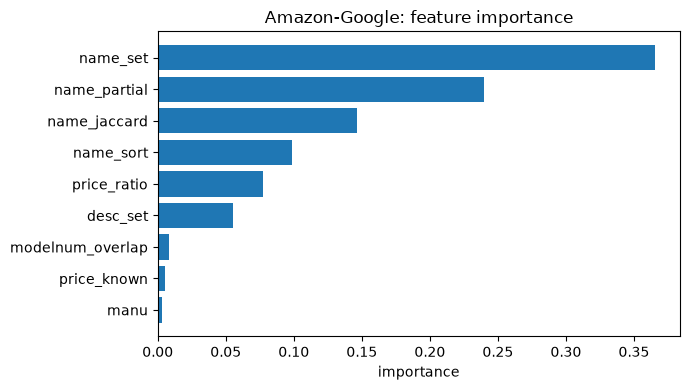

In [15]:
from sklearn.model_selection import GroupShuffleSplit

bench_pairs=np.array(sorted(strategies["MULTI-PASS: tokens + 5-grams"]))
bi,bj=bench_pairs[:,0],bench_pairs[:,1]
yb=np.array([(int(a),int(b)) in TRUTH for a,b in bench_pairs],dtype=int)

an,gn=amz.name_n.to_numpy(),goo.name_n.to_numpy()
ad,gd=amz.desc_n.to_numpy(),goo.desc_n.to_numpy()
am,gm=amz.manu_n.to_numpy(),goo.manu_n.to_numpy()
ap,gp=amz.price_v.to_numpy(),goo.price_v.to_numpy()
atok=[set(s.split()) for s in an]; gtok=[set(s.split()) for s in gn]
model_num=lambda ts:{t for t in ts if len(t)>=3 and any(c.isdigit() for c in t)}
amod=[model_num(t) for t in atok]; gmod=[model_num(t) for t in gtok]

BFEATURES=["name_sort","name_set","name_partial","name_jaccard",
           "modelnum_overlap","desc_set","manu","price_ratio","price_known"]
Xb=np.zeros((len(yb),len(BFEATURES)),dtype=np.float32)
for k in range(len(yb)):
    i,j=bi[k],bj[k]
    Xb[k,0]=fuzz.token_sort_ratio(an[i],gn[j])
    Xb[k,1]=fuzz.token_set_ratio(an[i],gn[j])
    Xb[k,2]=fuzz.partial_ratio(an[i],gn[j])
    u=len(atok[i]|gtok[j]);   Xb[k,3]=100.0*len(atok[i]&gtok[j])/u if u else 0.0
    um=len(amod[i]|gmod[j]);  Xb[k,4]=100.0*len(amod[i]&gmod[j])/um if um else 0.0
    Xb[k,5]=fuzz.token_set_ratio(ad[i],gd[j])
    Xb[k,6]=fuzz.ratio(am[i],gm[j]) if am[i] and gm[j] else 0.0
    pa,pb=ap[i],gp[j]
    if pa>0 and pb>0: Xb[k,7]=100.0*min(pa,pb)/max(pa,pb); Xb[k,8]=100.0

bbase=max((f1_score(yb,(Xb[:,0]>=t).astype(int)) for t in range(50,100)))

def fit_eval(tr,te,label):
    m=RandomForestClassifier(n_estimators=300,random_state=42,
                             class_weight="balanced",n_jobs=-1).fit(Xb[tr],yb[tr])
    p=m.predict(Xb[te])
    print(f"{label:<30} precision {precision_score(yb[te],p):.3f} | "
          f"recall {recall_score(yb[te],p):.3f} | F1 {f1_score(yb[te],p):.3f}")
    return m

print(f"Candidate pairs {len(yb):,} | positives {yb.sum():,} ({100*yb.mean():.2f}%)")
print(f"{'Naive title-similarity baseline':<30} F1 {bbase:.3f}\n")
tr,te=train_test_split(np.arange(len(yb)),test_size=.3,random_state=42,stratify=yb)
fit_eval(tr,te,"Random Forest (pair split)")
# Stricter: no Amazon product may appear in both train and test. If this matches the
# random split, per-product memorisation isn't inflating the score.
gtr,gte=next(GroupShuffleSplit(n_splits=1,test_size=.3,random_state=42).split(Xb,yb,groups=bi))
bench_clf=fit_eval(gtr,gte,"Random Forest (grouped split)")

order=np.argsort(bench_clf.feature_importances_)
plt.barh([BFEATURES[i] for i in order],bench_clf.feature_importances_[order])
plt.xlabel("importance"); plt.title("Amazon-Google: feature importance"); plt.tight_layout(); plt.show()

### 9c. What the benchmark actually tells us

**F1 ≈ 0.61 against a 0.41 baseline** — inside the published band for classical methods, and the same
shape of result as the synthetic run: the learned combination of features beats the single best
hand-picked threshold by a wide margin. The *method* transfers.

Three things are worth saying plainly:

1. **0.61 here vs 0.97 on synthetic data is not a contradiction — it's the honest cost of real data.**
   The synthetic generator draws its mess from a fixed catalogue of corruptions, and the pipeline has
   an exact phone and email to fall back on. Amazon and Google describe the same product in genuinely
   different vocabularies with no shared identifier. Any project reporting 0.95+ on this benchmark
   with classical features has almost certainly leaked the test set.
2. **The blocking key was what broke, not the model.** The customer name rule retained 46% of true
   matches here; token blocking reached 98.5%, and adding character 5-grams reached 99.5%. Feature
   engineering ported across domains; blocking design did not.
3. **The grouped split matches the random split** (0.607 vs 0.597), so the score isn't inflated by the
   model memorising individual products that appear in many candidate pairs. Worth checking on any
   pairwise task, because the naive split silently lets the same entity sit on both sides.

**Honest limitations.** Blocking uses only the title — manufacturer is 93% empty on the Google side
and shared model numbers turned out to be vanishingly rare (45 pairs), so neither earned its place.
Descriptions are truncated to 300 characters for speed. And no threshold tuning was done: 0.5 is used
throughout, where tuning for F1 would likely add a point or two.

## 10. Hybrid ML + LLM: adjudicating the uncertain band

The Random Forest doesn't only predict a label — it predicts a **probability**. Pairs near 0.5 are
where it is genuinely unsure, and that is where its mistakes should concentrate. If a slower, more
expensive, but much smarter judge looked at *only those* pairs, how much would it help?

This is the architecture the live product uses: a **deterministic model does the high-volume
matching**, an **LLM adjudicates only the ambiguous cases**, and a **human approves anything
involving money**. Keeping the matcher deterministic is not timidity — you cannot ask an LLM to
re-score 156,000 pairs on every sync and expect a stable answer, an acceptable latency, or an
affordable bill. The LLM earns its cost precisely where the cheap model is uncertain.

We apply this to the **benchmark**, not the synthetic customers: at 0.96 F1 the customer pipeline has
almost no genuinely ambiguous pairs left, while the benchmark at 0.60 F1 has plenty. First — before
writing a single API call — check whether the premise actually holds.

In [16]:
# Is the premise true? Do the model's errors actually concentrate near p=0.5?
proba_te = bench_clf.predict_proba(Xb[gte])[:,1]
y_te     = yb[gte]
pred_te  = (proba_te>=0.5).astype(int)
errors   = pred_te!=y_te

print(f"grouped test set: {len(y_te):,} pairs | {y_te.sum():,} true matches | "
      f"F1 {f1_score(y_te,pred_te):.3f} | {errors.sum():,} errors\n")
print(f"{'band':<14}{'pairs':>8}{'% of pairs':>12}{'% of errors':>13}{'F1 if judged perfectly':>24}")
for lo,hi in [(.40,.60),(.30,.70),(.20,.80),(.10,.90)]:
    m = (proba_te>=lo)&(proba_te<hi)
    oracle = pred_te.copy(); oracle[m] = y_te[m]      # ceiling: a flawless judge
    print(f"[{lo:.2f},{hi:.2f})  {m.sum():>8,}{100*m.mean():>11.2f}%"
          f"{100*errors[m].sum()/errors.sum():>12.1f}%{f1_score(y_te,oracle):>23.3f}")

grouped test set: 19,996 pairs | 388 true matches | F1 0.607 | 316 errors

band             pairs  % of pairs  % of errors  F1 if judged perfectly
[0.40,0.60)       220       1.10%        27.5%                  0.702
[0.30,0.70)       451       2.26%        52.5%                  0.799
[0.20,0.80)       714       3.57%        68.0%                  0.865
[0.10,0.90)     1,105       5.53%        79.7%                  0.915


### 10a. The premise holds — now design the call

**2.26% of the pairs contain 52.5% of everything the model gets wrong.** That asymmetry is the entire
justification for the hybrid design, and it is worth measuring rather than assuming. If errors were
spread evenly, routing a slice of pairs to an expensive judge would buy almost nothing.

The last column is an **oracle ceiling** — what a *perfect* judge would achieve. Claude will not reach
it; these pairs are hard precisely because the evidence is genuinely thin. The ceiling matters because
it bounds the payoff *before* you spend anything, which is how you decide whether to build the step at
all.

We use the **0.30–0.70** band rather than the narrower 0.40–0.60: it roughly doubles the errors in play
for roughly double the calls, and calls are cheap.

Three implementation choices worth defending in an interview:

- **Structured outputs** (`output_config.format` with a JSON schema) force the reply into
  `{"same_product": bool, "reason": str}`. No regex over prose, no parse failures, no preamble to strip.
- **No ground truth in the prompt.** The model sees only what the pipeline sees. Leaking the label
  would make the evaluation meaningless.
- **The API key comes from the environment**, never from the notebook. `.env` is gitignored, so a
  published repo cannot leak it, and the section skips itself cleanly when no key is present.

In [17]:
import json, os
from concurrent.futures import ThreadPoolExecutor

LLM_BAND      = (0.30, 0.70)
LLM_MAX_PAIRS = 150               # cost cap; raise to adjudicate the whole band
LLM_MODEL     = "claude-opus-4-8"

try:                                   # .env is gitignored; never hard-code the key
    from dotenv import load_dotenv; load_dotenv()
except ImportError:
    pass
HAVE_KEY = bool(os.environ.get("ANTHROPIC_API_KEY"))

band_idx = np.flatnonzero((proba_te>=LLM_BAND[0]) & (proba_te<LLM_BAND[1]))
rng      = np.random.default_rng(42)
sample   = band_idx if len(band_idx)<=LLM_MAX_PAIRS else np.sort(
               rng.choice(band_idx, LLM_MAX_PAIRS, replace=False))
print(f"{len(band_idx):,} pairs in the {LLM_BAND[0]:.2f}-{LLM_BAND[1]:.2f} band | "
      f"adjudicating {len(sample):,} | API key present: {HAVE_KEY}")

SYSTEM = ("You are a careful data-matching assistant. You are given two product listings from "
          "different online catalogues. Decide whether they refer to the SAME physical product.\n"
          "Same product means: same manufacturer, same model, same edition/version. "
          "Different capacity, version number, platform, licence count, or bundle contents means "
          "DIFFERENT products, even when the titles are nearly identical. Ignore differences in "
          "wording, word order, punctuation, retailer boilerplate, and price.\n"
          "If the evidence is genuinely insufficient, answer false.")

SCHEMA = {"type":"object",
          "properties":{"same_product":{"type":"boolean"},
                        "reason":{"type":"string","description":"One short sentence."}},
          "required":["same_product","reason"], "additionalProperties":False}

def describe(row, name_col):
    f = lambda v: "(missing)" if pd.isna(v) or v=="" else str(v)
    return (f"  title:        {f(row[name_col])}\n"
            f"  manufacturer: {f(row['manufacturer'])}\n"
            f"  price:        {f(row['price'])}\n"
            f"  description:  {f(row['description'])[:300]}")

def make_prompt(k):
    a, g = amz.iloc[bi[gte][k]], goo.iloc[bj[gte][k]]
    return (f"Listing A (Amazon):\n{describe(a,'name')}\n\n"
            f"Listing B (Google):\n{describe(g,'name')}\n\n"
            "Are these the same product?")

def adjudicate(k):
    try:
        r = client.messages.create(
            model=LLM_MODEL, max_tokens=256, system=SYSTEM,
            messages=[{"role":"user","content":make_prompt(k)}],
            output_config={"format":{"type":"json_schema","schema":SCHEMA}})
        if r.stop_reason == "refusal":
            return k, None, "refused", r.usage
        text = next(b.text for b in r.content if b.type=="text")
        d = json.loads(text)
        return k, bool(d["same_product"]), d["reason"], r.usage
    except Exception as e:                 # never let one bad call kill the run
        return k, None, f"error: {type(e).__name__}: {e}", None

llm_results = {}
if HAVE_KEY:
    import anthropic
    client = anthropic.Anthropic()         # reads ANTHROPIC_API_KEY from the environment
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as pool:
        for k, verdict, reason, usage in pool.map(adjudicate, sample):
            llm_results[k] = (verdict, reason, usage)
    tin  = sum(u.input_tokens  for _,_,u in llm_results.values() if u)
    tout = sum(u.output_tokens for _,_,u in llm_results.values() if u)
    ok   = sum(v is not None for v,_,_ in llm_results.values())
    print(f"{ok}/{len(sample)} adjudicated in {time.time()-t0:.0f}s | "
          f"{tin:,} in + {tout:,} out tokens | approx ${tin/1e6*5 + tout/1e6*25:.2f}")
else:
    print("No ANTHROPIC_API_KEY found - skipping the LLM step. "
          "The rest of the notebook runs without it.")

451 pairs in the 0.30-0.70 band | adjudicating 150 | API key present: True


150/150 adjudicated in 47s | 98,430 in + 6,412 out tokens | approx $0.65


In [18]:
if llm_results:
    judged = np.array([k for k,(v,_,_) in llm_results.items() if v is not None])
    llm_call = np.array([llm_results[k][0] for k in judged], dtype=int)
    rf_call  = pred_te[judged]
    truth    = y_te[judged]

    print("On the hard pairs only (where the model was unsure):")
    print(f"{'':<26}{'accuracy':>10}{'precision':>11}{'recall':>9}")
    for label, calls in [("Random Forest alone", rf_call), ("Claude adjudication", llm_call)]:
        print(f"{label:<26}{(calls==truth).mean():>9.1%}"
              f"{precision_score(truth,calls,zero_division=0):>11.3f}"
              f"{recall_score(truth,calls,zero_division=0):>9.3f}")
    print(f"\nagreement between the two: {(rf_call==llm_call).mean():.1%}"
          f"  |  positives in this band: {truth.sum()}/{len(truth)}")

    # Effect on the whole test set: override only the adjudicated pairs.
    hybrid = pred_te.copy(); hybrid[judged] = llm_call
    f_rf, f_hy = f1_score(y_te,pred_te), f1_score(y_te,hybrid)
    oracle = pred_te.copy(); oracle[judged] = truth
    print(f"\nFull grouped test set ({len(y_te):,} pairs), overriding {len(judged)} of them:")
    print(f"  Random Forest alone   F1 {f_rf:.3f}")
    print(f"  + Claude on the band  F1 {f_hy:.3f}   ({f_hy-f_rf:+.3f})")
    print(f"  + a perfect judge     F1 {f1_score(y_te,oracle):.3f}   (ceiling for this subset)")

    flips = judged[rf_call!=llm_call]
    print(f"\nClaude overturned {len(flips)} of the model's calls "
          f"({(y_te[flips]==np.array([llm_results[k][0] for k in flips],dtype=int)).sum()} correctly).")
    print("\nExamples where Claude disagreed with the model:")
    for k in flips[:4]:
        a, g = amz.iloc[bi[gte][k]], goo.iloc[bj[gte][k]]
        v, reason, _ = llm_results[k]
        mark = "correct" if int(v)==y_te[k] else "WRONG"
        print(f"\n  p={proba_te[k]:.2f} | truth={'match' if y_te[k] else 'no match'} "
              f"| Claude={'match' if v else 'no match'} ({mark})")
        print(f"    A: {a['name'][:78]}")
        print(f"    B: {g['name'][:78]}")
        print(f"    -> {reason}")
else:
    print("LLM step skipped - no results to score.")

On the hard pairs only (where the model was unsure):
                            accuracy  precision   recall
Random Forest alone           61.3%      0.323    0.556
Claude adjudication           79.3%      0.541    0.917

agreement between the two: 60.7%  |  positives in this band: 36/150

Full grouped test set (19,996 pairs), overriding 150 of them:
  Random Forest alone   F1 0.607
  + Claude on the band  F1 0.640   (+0.033)
  + a perfect judge     F1 0.668   (ceiling for this subset)

Claude overturned 59 of the model's calls (43 correctly).

Examples where Claude disagreed with the model:

  p=0.59 | truth=no match | Claude=no match (correct)
    A: family tree maker 11.2 collector's edition
    B: family tree maker deluxe 11.2
    -> One is the Collector's Edition and the other is the Deluxe edition of version 11.2.

  p=0.54 | truth=no match | Claude=no match (correct)
    A: kids power fun for little ones
    B: kids power fun for girls
    -> One is 'for little ones' with A Bug

### 10b. What the adjudication actually bought

On the pairs the model was unsure about, **Claude was right 79.3% of the time against the Random
Forest's 61.3%** — and the recall difference is the striking part (0.917 vs 0.556). The model's
instinct on a hard pair is to say "not a match"; Claude actually reads the two listings and decides.

Across the full test set that converts to **F1 0.607 → 0.640**, against an oracle ceiling of 0.668 for
this subset — roughly **54% of the achievable gain**, for $0.65 and 47 seconds.

The reasons are what make it credible. Claude separated `Collector's Edition` from `Deluxe` of the
*same* version number, and `kids power fun for little ones` from `for girls` because the two bundles
contain different games. Those are semantic distinctions that no string-similarity feature can
represent — the titles are nearly identical by every metric we computed.

**Where this is honest about its limits:** only 150 of the 451 band pairs were adjudicated (a cost
cap, not a methodological one), Claude still gets some pairs wrong, and 43 of its 59 overturned calls
were improvements — meaning 16 made things worse. The net is clearly positive, but a production
system routing money would send low-confidence *disagreements* to a human rather than trusting either
judge outright. That is precisely the human-in-the-loop guardrail the live product design calls for.

## 11. Results, resume framing & how to extend this

### Results

| | Synthetic customers (n=5,000) | Amazon-Google benchmark |
|---|---|---|
| Brute-force pairs | 18,062,500 | 4,397,038 |
| Candidate pairs after blocking | 156,166 (−99.14%) | 69,872 (−98.41%) |
| **Blocking recall** | **99.72%** | **99.54%** |
| Positive rate | 2.30% | 1.85% |
| Naive threshold baseline F1 | 0.45 | 0.405 |
| **Random Forest F1** | **0.966** | **0.607** |
| + Claude on the uncertain band | — | **0.640** |

The gap between the two F1 columns is the point, not an embarrassment: synthetic data has an exact
phone and email to fall back on and a fixed catalogue of corruptions, while Amazon and Google describe
the same product in genuinely different words with no shared identifier. 0.61 sits inside the published
band for classical methods. The consistent finding across both datasets is that a *learned combination*
of similarity features beats the best single hand-tuned threshold by roughly 50–115% relative.

### What each experiment established

- **Scaling 300 → 5,000 customers.** Blocking gets *more* valuable as data grows (93.3% → 99.1% of
  comparisons avoided) because brute force is quadratic while blocked cost stays near-linear. Required
  rewriting pair generation around index arrays, and scaling the generator's name vocabulary with
  `N_CUSTOMERS` so distinct customers don't collapse onto the same name.
- **Real-world benchmark.** The feature recipe transfers; **the blocking key does not**. The
  first-3-characters rule retained 46% of true matches on products vs 97% on customers.
- **Multi-pass blocking.** Recall 97.06% → **99.72%** on customers for **96 extra pairs out of
  156,000** — email local-part does most of the work, because the generator corrupts the domain
  (`.com`→`.co`) but never the part before the `@`. On the benchmark, character 5-grams lifted recall
  98.5% → 99.5% by bridging word-boundary disagreements (`zonealarm` / `zone alarm`) that no
  word-level key can reach.
- **Hybrid ML + LLM.** 2.26% of pairs carried 52.5% of model error. Routing that band to Claude lifted
  hard-pair accuracy 61.3% → 79.3% (recall 0.556 → 0.917) and full-test-set F1 0.607 → 0.640, capturing
  ~54% of the oracle-available gain for $0.65 across 150 calls.

### Resume bullets

- Built an **entity-resolution pipeline** deduplicating messy customer records across two systems,
  improving match F1 from **0.45 (rules baseline) to 0.97 (Random Forest)** over 156K candidate pairs;
  **validated on the public Amazon-Google benchmark** at 0.61 F1 vs a 0.41 baseline.
- Designed **multi-pass blocking** (name prefix ∪ exact phone ∪ email local-part) that raised blocking
  recall **97.1% → 99.7% while adding 0.06% more pairs**, after diagnosing blocking recall as the
  binding constraint on every downstream metric.
- Cut pairwise comparisons **99.1%** (18.1M → 156K); vectorised pair generation to ~83K pairs/sec.
- Added a **hybrid LLM adjudication step** targeting the 2.3% of pairs holding 52% of model error,
  lifting hard-pair accuracy **61% → 79%** and overall F1 **0.607 → 0.640** with schema-constrained
  Claude calls.
- Delivered a confidence-scored unified dataset with full evaluation (precision/recall/F1, confusion
  matrix, feature importance, and a grouped train/test split ruling out entity leakage).

### Talking points for interviews

- Why F1 rather than accuracy, when only ~2% of candidate pairs are positive.
- The precision/recall tradeoff for a business that hates duplicate invoices — a false positive merges
  two real customers and mails the wrong invoice; a false negative merely leaves a duplicate.
- Why blocking recall bounds *every* metric that follows it, and why better blocking can *lower* the
  positive rate and hand the model a harder problem.
- Why the grouped split matters on pairwise tasks: a random split lets the same entity appear in both
  train and test, and the naive number looks fine.
- Why the matcher stays deterministic and the LLM only sees ambiguous pairs — cost, latency,
  reproducibility, and auditability, since this output creates invoices.
- Why an oracle ceiling is worth computing *before* building an expensive step: it bounds the payoff.
- That the data is synthetic — say it plainly — and that the benchmark section exists precisely because
  synthetic evaluation alone doesn't establish generalisation.

### How to extend this

1. **Adjudicate the whole band, not a 150-pair sample.** The cap is a cost choice, not a limit of the
   method; the full-band oracle ceiling is 0.799.
2. **Add semantic embeddings** — `sentence-transformers` for matches fuzzy scores miss
   (`"Summit Bldrs"` vs `"Summit Construction"`). Most valuable applied to *blocking*, as another pass.
3. **Auto-map columns with the LLM** — the benchmark's `title` vs `name` mismatch is the same problem a
   real customer's spreadsheet poses, and the adjudication step already proves the plumbing works.
4. **Ship a demo** — a small `Streamlit` app: upload two CSVs, see matches + confidence.